# SHIELD Healthy-Envelope Validation

This report uses the March 2 recollection data for the DFRobot SEN0140 and Pololu MinIMU-9 sensors.

Pipeline:
1. Calibrate on healthy calibrated data across benign operating conditions.
2. Extract multiaxis physics-based features.
3. Measure KL/JSD divergence against pooled healthy references.
4. Map the health score into `[0, 1]`, where `1 = healthy`.
5. Validate that healthy shaking stays healthy.
6. Inject synthetic faults and validate that health decreases.

Extension: evaluate against real fault data once it is collected.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display

OUT_DIR = Path('figures/shield_health_validation')
summary = json.loads((OUT_DIR / 'summary.json').read_text())
condition_summary = pd.read_csv(OUT_DIR / 'condition_summary.csv')
fault_results = pd.read_csv(OUT_DIR / 'fault_results.csv')

display(Markdown(f"**Data root:** `{summary['data_root']}`"))
display(condition_summary)

**Data root:** `/Users/gilliam/Desktop/Project Shield/datasets/SHIELD Data Collection/march 2 data (recollection of pololu and dfrobot)`

,sensor,condition,condition_label,rpm,mean_health_score,std_health_score,mean_health_score_raw,mean_div_mean_kl,mean_div_mean_jsd
0,DFRobot,stationary,Stationary,0,1.000000,0.000000,0.724818,2.715258,0.251915
1,DFRobot,40_rpm,40 RPM,40,1.000000,0.000000,0.479543,2.267509,0.147202
2,DFRobot,80_rpm,80 RPM,80,1.000000,0.000000,0.809658,1.481143,0.142000
3,DFRobot,120_rpm,120 RPM,120,1.000000,0.000000,0.761833,1.363141,0.178900
4,DFRobot,160_rpm,160 RPM,160,0.999815,0.003055,1.014059,2.326154,0.245771
5,DFRobot,200_rpm,200 RPM,200,0.952746,0.067623,1.422136,2.443503,0.289034
6,Pololu,stationary,Stationary,0,1.000000,0.000000,0.708321,2.393729,0.361486
7,Pololu,40_rpm,40 RPM,40,1.000000,0.000000,0.803227,2.803652,0.173821
8,Pololu,80_rpm,80 RPM,80,1.000000,0.000000,0.691282,1.606756,0.147465
9,Pololu,120_rpm,120 RPM,120,1.000000,0.000000,0.590406,1.601359,0.198022


In [2]:
display(Markdown('## Health Calibration'))
for sensor, calibration in summary['health_calibration'].items():
    display(Markdown(f"### {sensor}"))
    display(pd.DataFrame([calibration]))

display(Markdown('## Selected Quality Features'))
for sensor, feats in summary['selected_features'].items():
    display(Markdown(f"### {sensor}"))
    display(pd.DataFrame({k: pd.Series(v) for k, v in feats.items()}))

## Health Calibration

### DFRobot

,healthy_quantile,healthy_threshold,healthy_scale
0,0.95,1.42586,0.654275


### Pololu

,healthy_quantile,healthy_threshold,healthy_scale
0,0.95,1.716711,0.998905


## Selected Quality Features

### DFRobot

,stable,sensitive,mandatory,all
0,AccZ_rms,AccY_mean,AccX_sq_snr,AccX_sq_snr
1,AccZ_modwt_a_rms,AccZ_quantile_25,AccX_sq_noise_floor,AccX_sq_noise_floor
2,AccZ_mean,AccY_modwt_a_rms,AccX_sq_baseline_stability,AccX_sq_baseline_stability
3,AccZ_modwt_total_energy,AccZ_modwt_a_entropy,AccY_sq_snr,AccY_sq_snr
4,AccZ_modwt_a_energy,NaN,AccY_sq_noise_floor,AccY_sq_noise_floor
5,AccZ_quantile_50,NaN,AccY_sq_baseline_stability,AccY_sq_baseline_stability
6,AccY_modwt_a_energy,NaN,AccZ_sq_snr,AccZ_sq_snr
7,AccZ_quantile_75,NaN,AccZ_sq_noise_floor,AccZ_sq_noise_floor
8,NaN,NaN,AccZ_sq_baseline_stability,AccZ_sq_baseline_stability
9,NaN,NaN,GyroX_sq_snr,GyroX_sq_snr


### Pololu

,stable,sensitive,mandatory,all
0,AccZ_modwt_a_rms,AccZ_quantile_25,AccX_sq_snr,AccX_sq_snr
1,AccZ_mean,AccY_modwt_a_rms,AccX_sq_noise_floor,AccX_sq_noise_floor
2,AccZ_rms,AccY_mean,AccX_sq_baseline_stability,AccX_sq_baseline_stability
3,AccZ_modwt_a_energy,AccY_quantile_50,AccY_sq_snr,AccY_sq_snr
4,AccZ_modwt_total_energy,NaN,AccY_sq_noise_floor,AccY_sq_noise_floor
5,AccZ_quantile_50,NaN,AccY_sq_baseline_stability,AccY_sq_baseline_stability
6,AccZ_modwt_a_entropy,NaN,AccZ_sq_snr,AccZ_sq_snr
7,AccZ_quantile_75,NaN,AccZ_sq_noise_floor,AccZ_sq_noise_floor
8,NaN,NaN,AccZ_sq_baseline_stability,AccZ_sq_baseline_stability
9,NaN,NaN,GyroX_sq_snr,GyroX_sq_snr


## Raw vs Calibrated Sanity

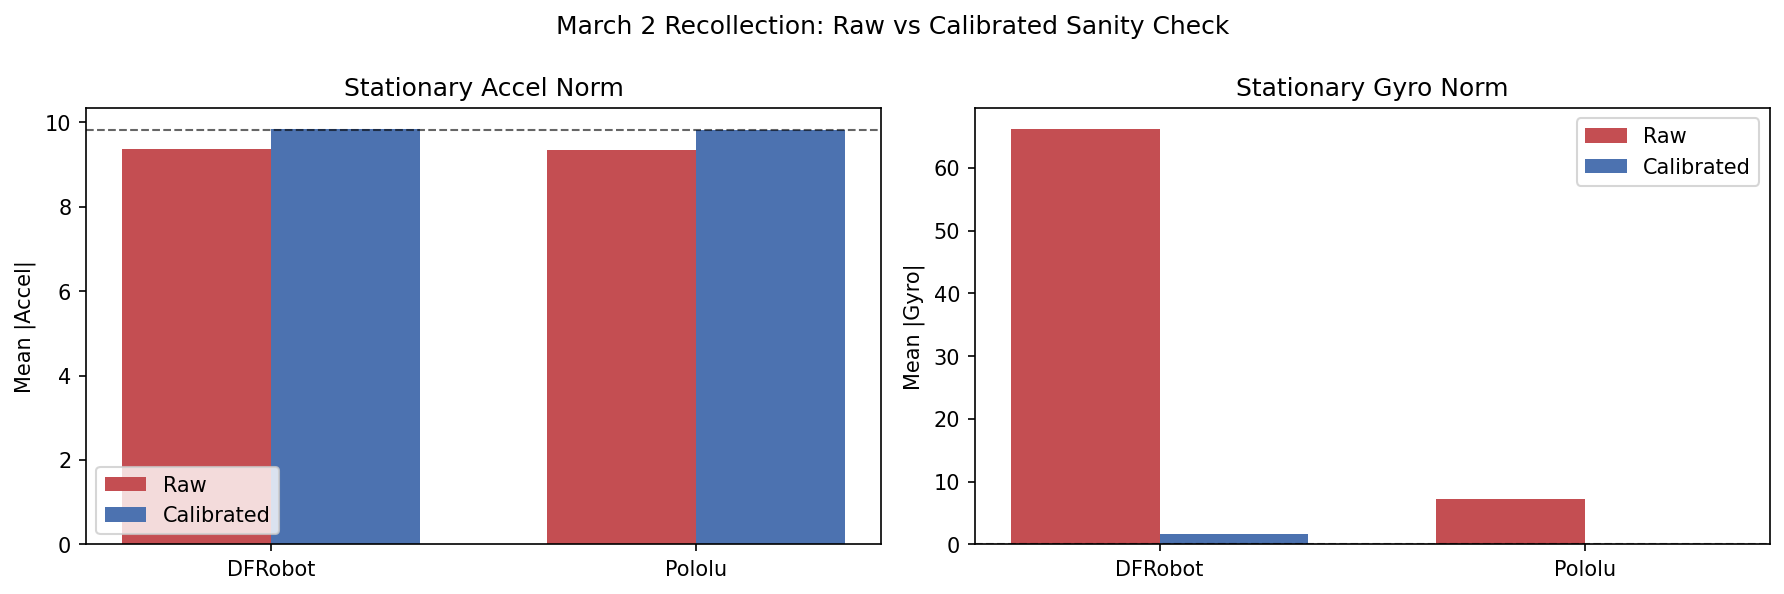

## MODWT Stationary Decomposition

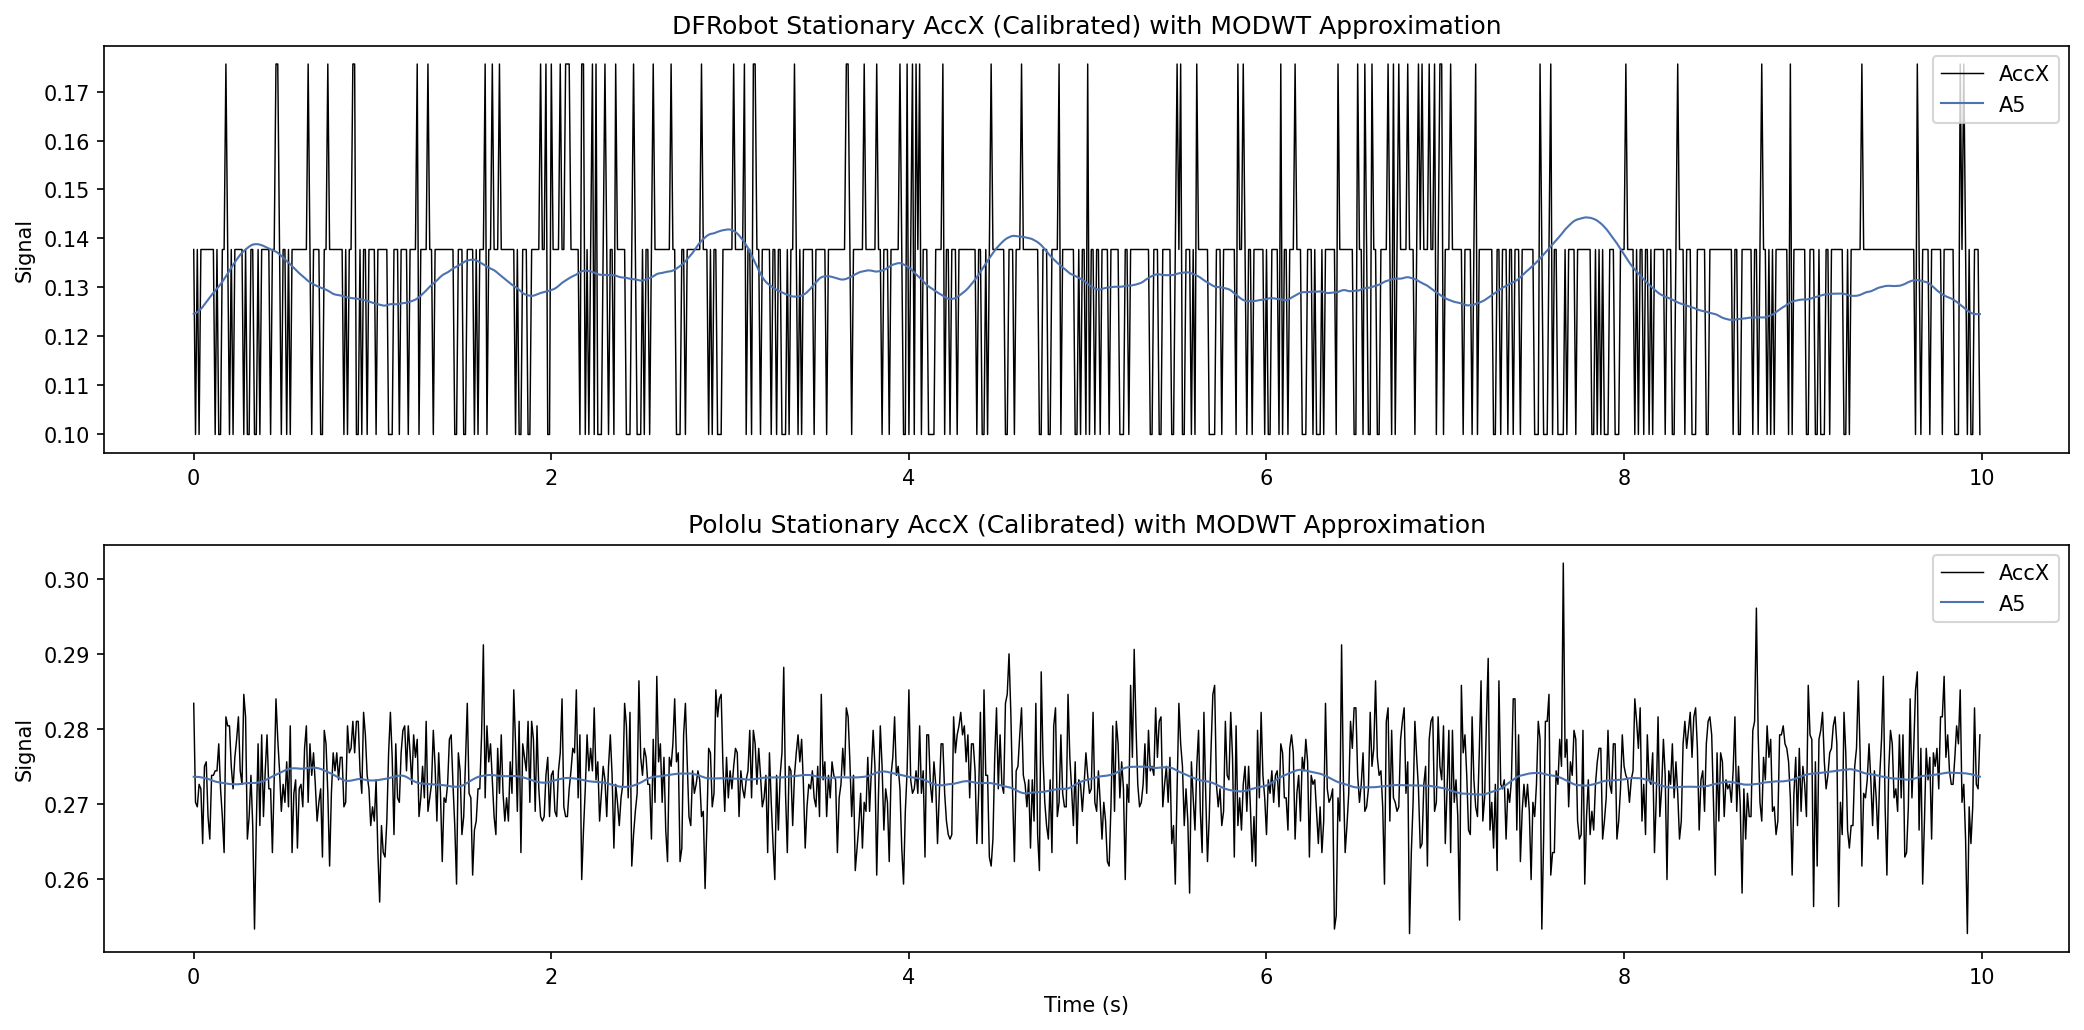

## Healthy Condition Summary

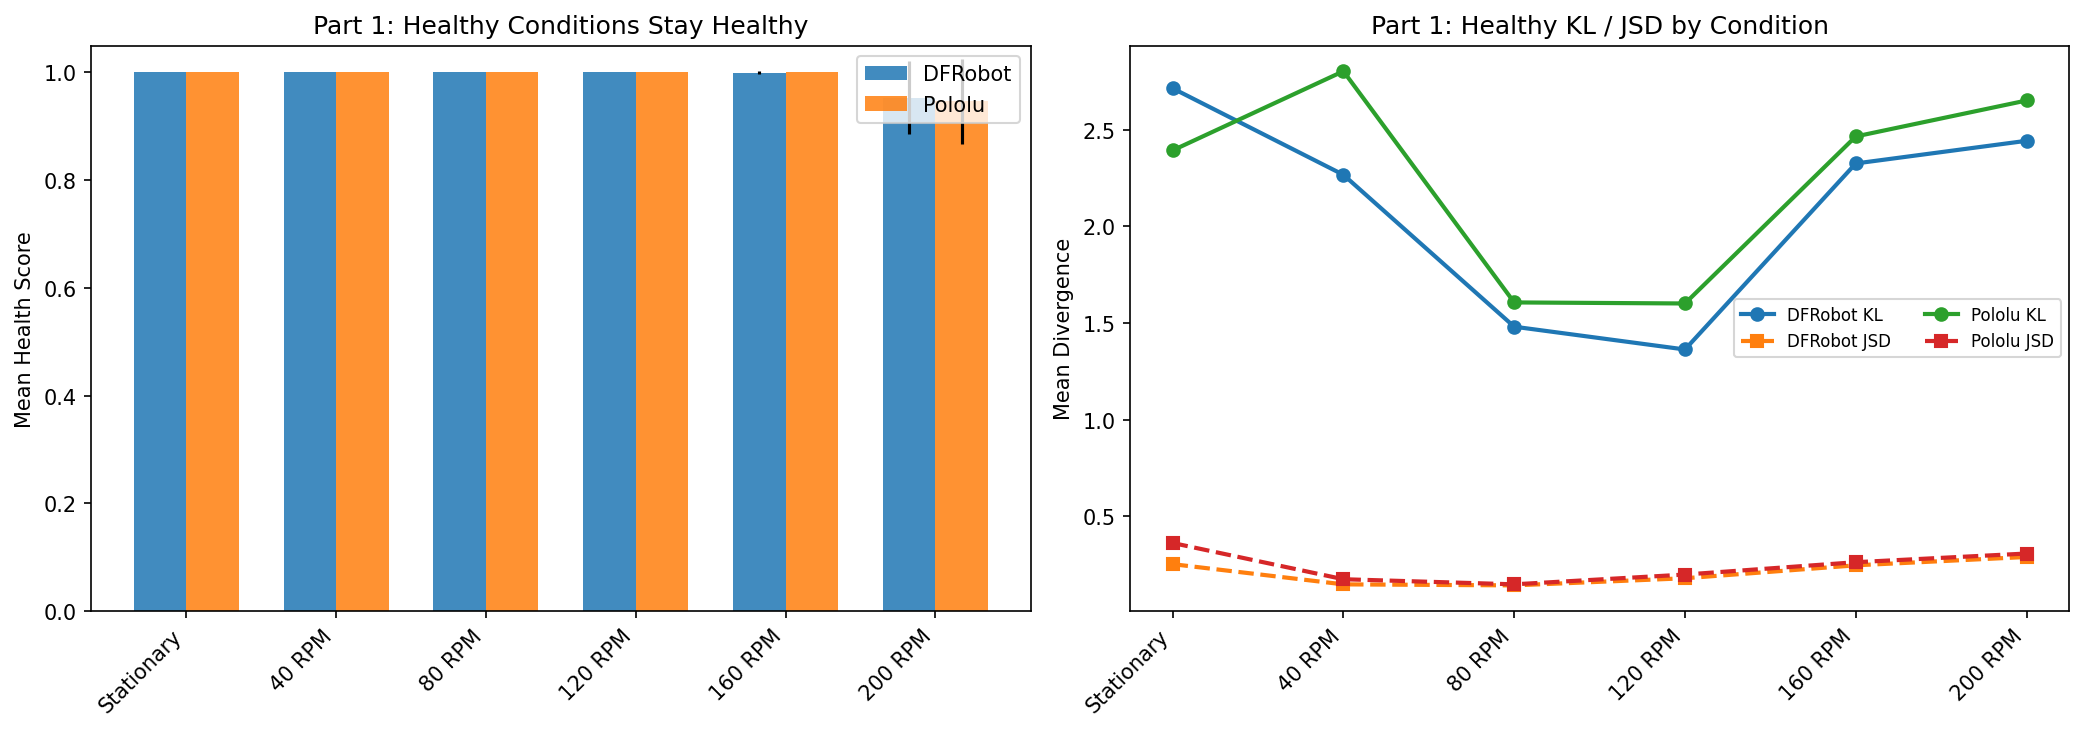

## Healthy Health Timeline

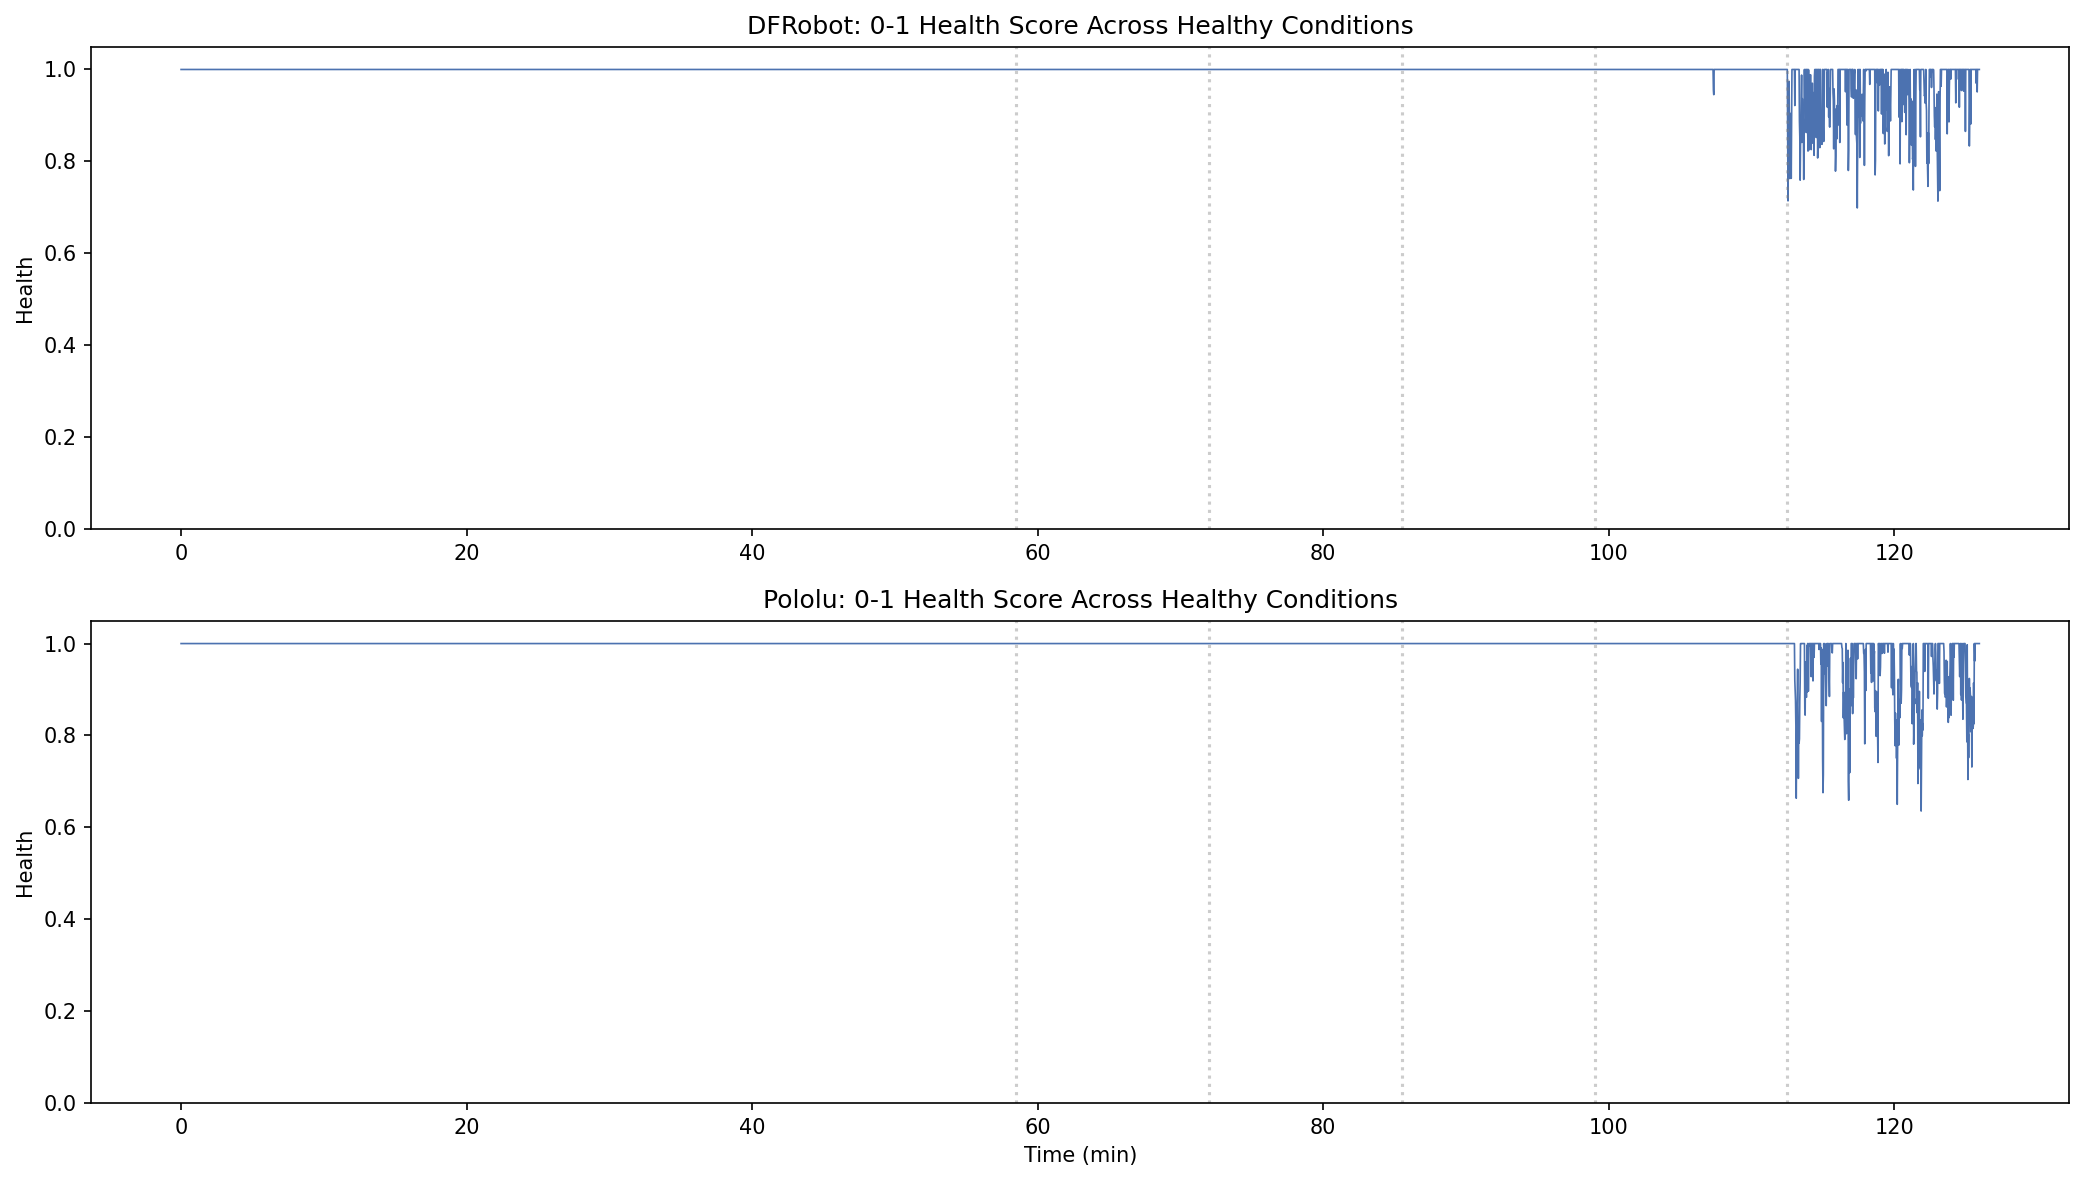

## Healthy Divergence Timeline

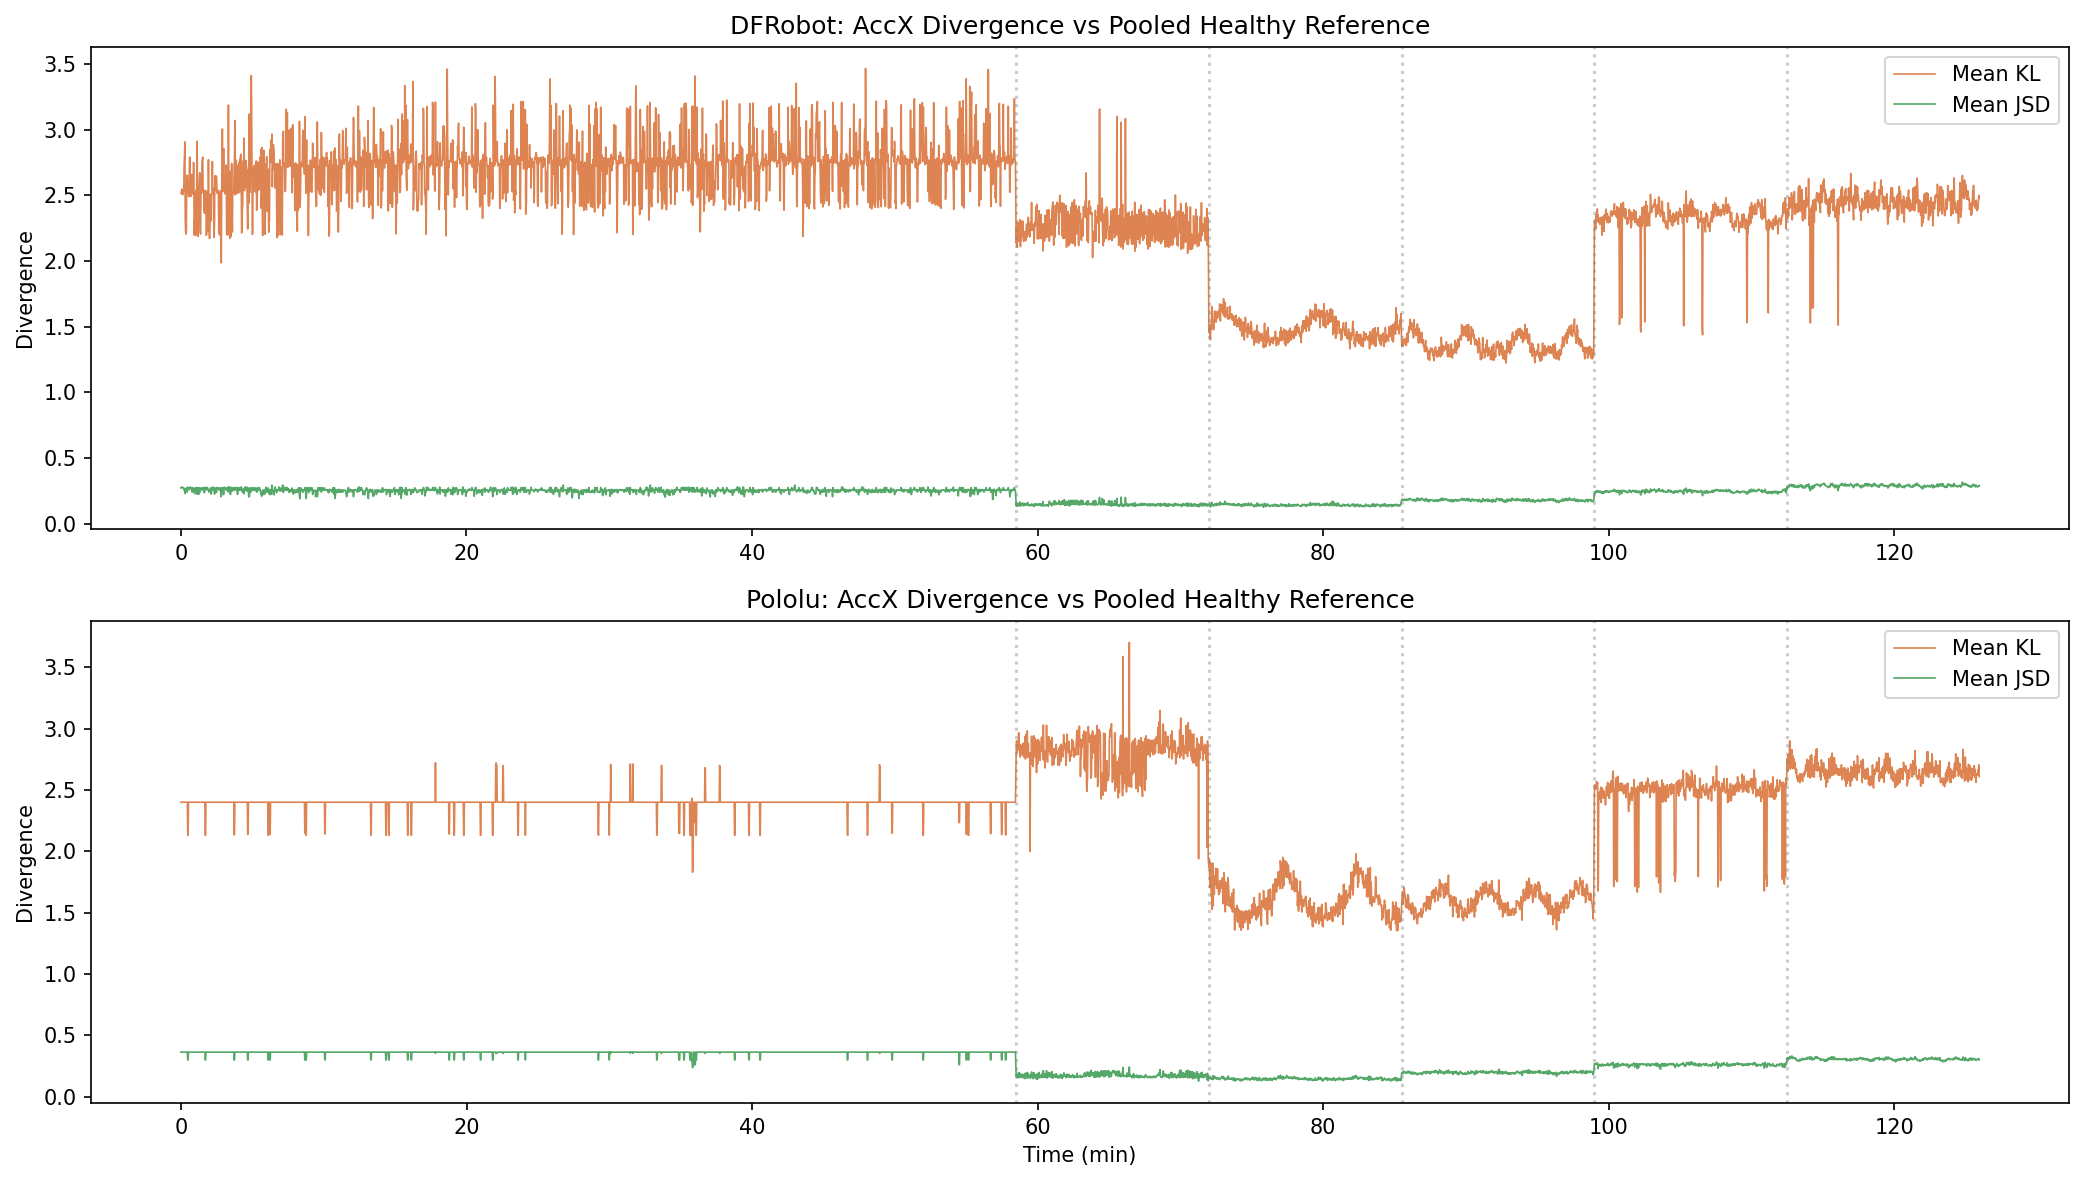

## Cross-Sensor Divergence

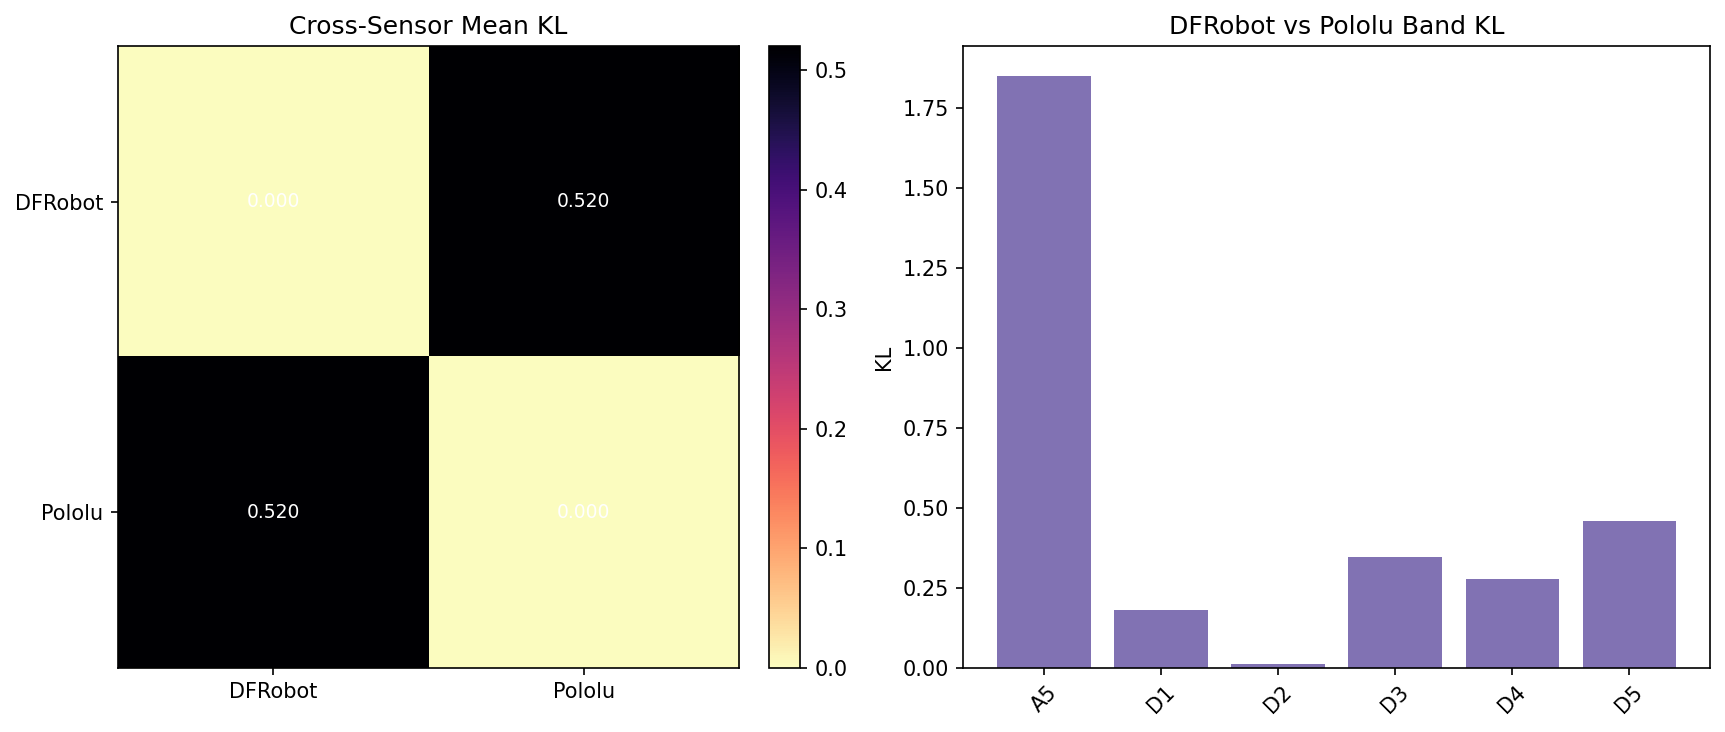

## Fault Health Response

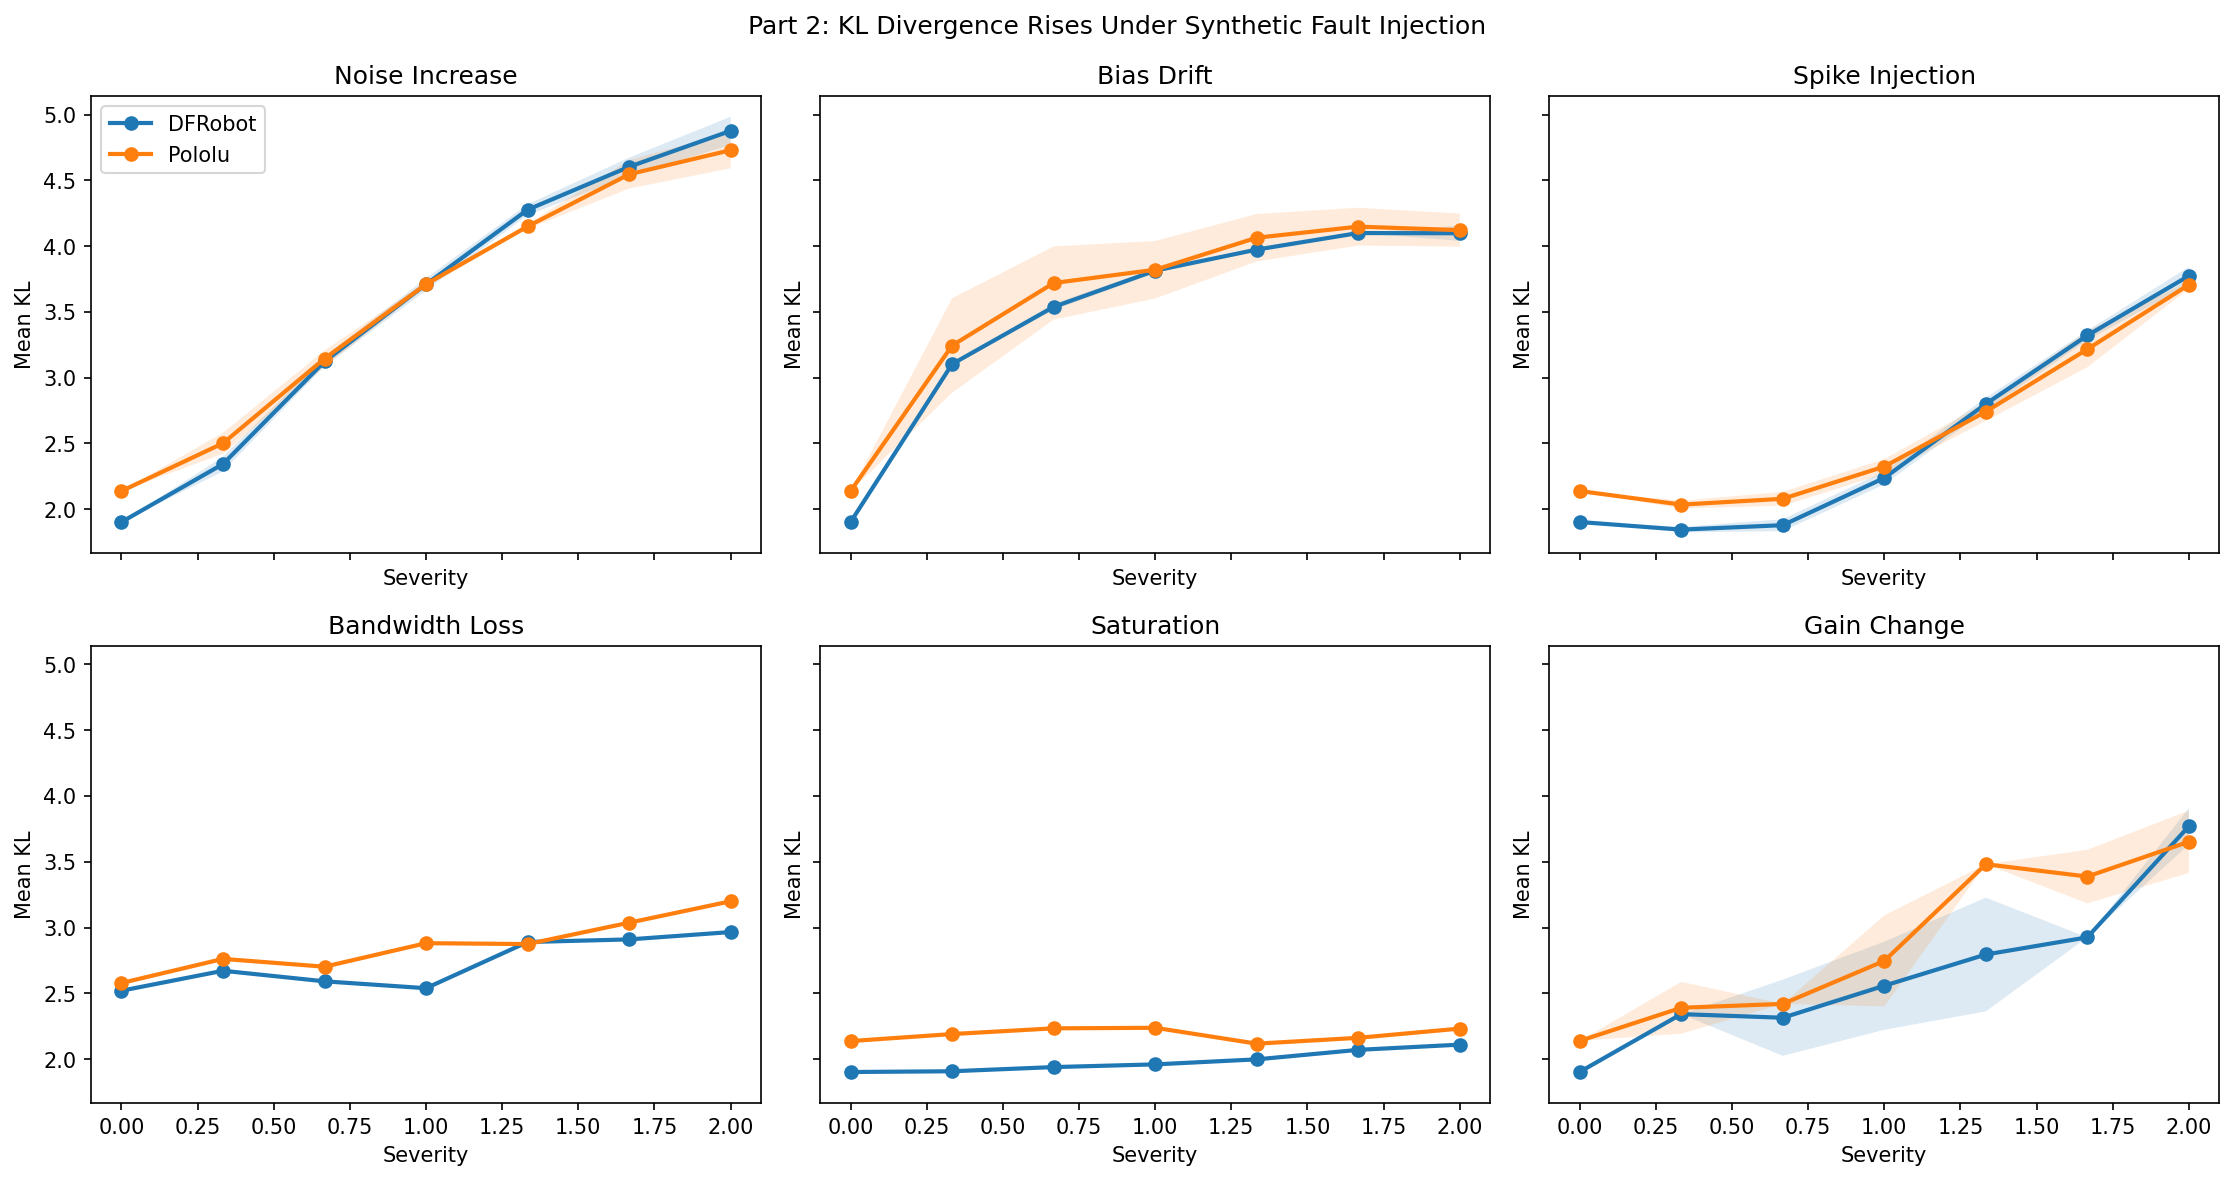

## Fault Divergence Response

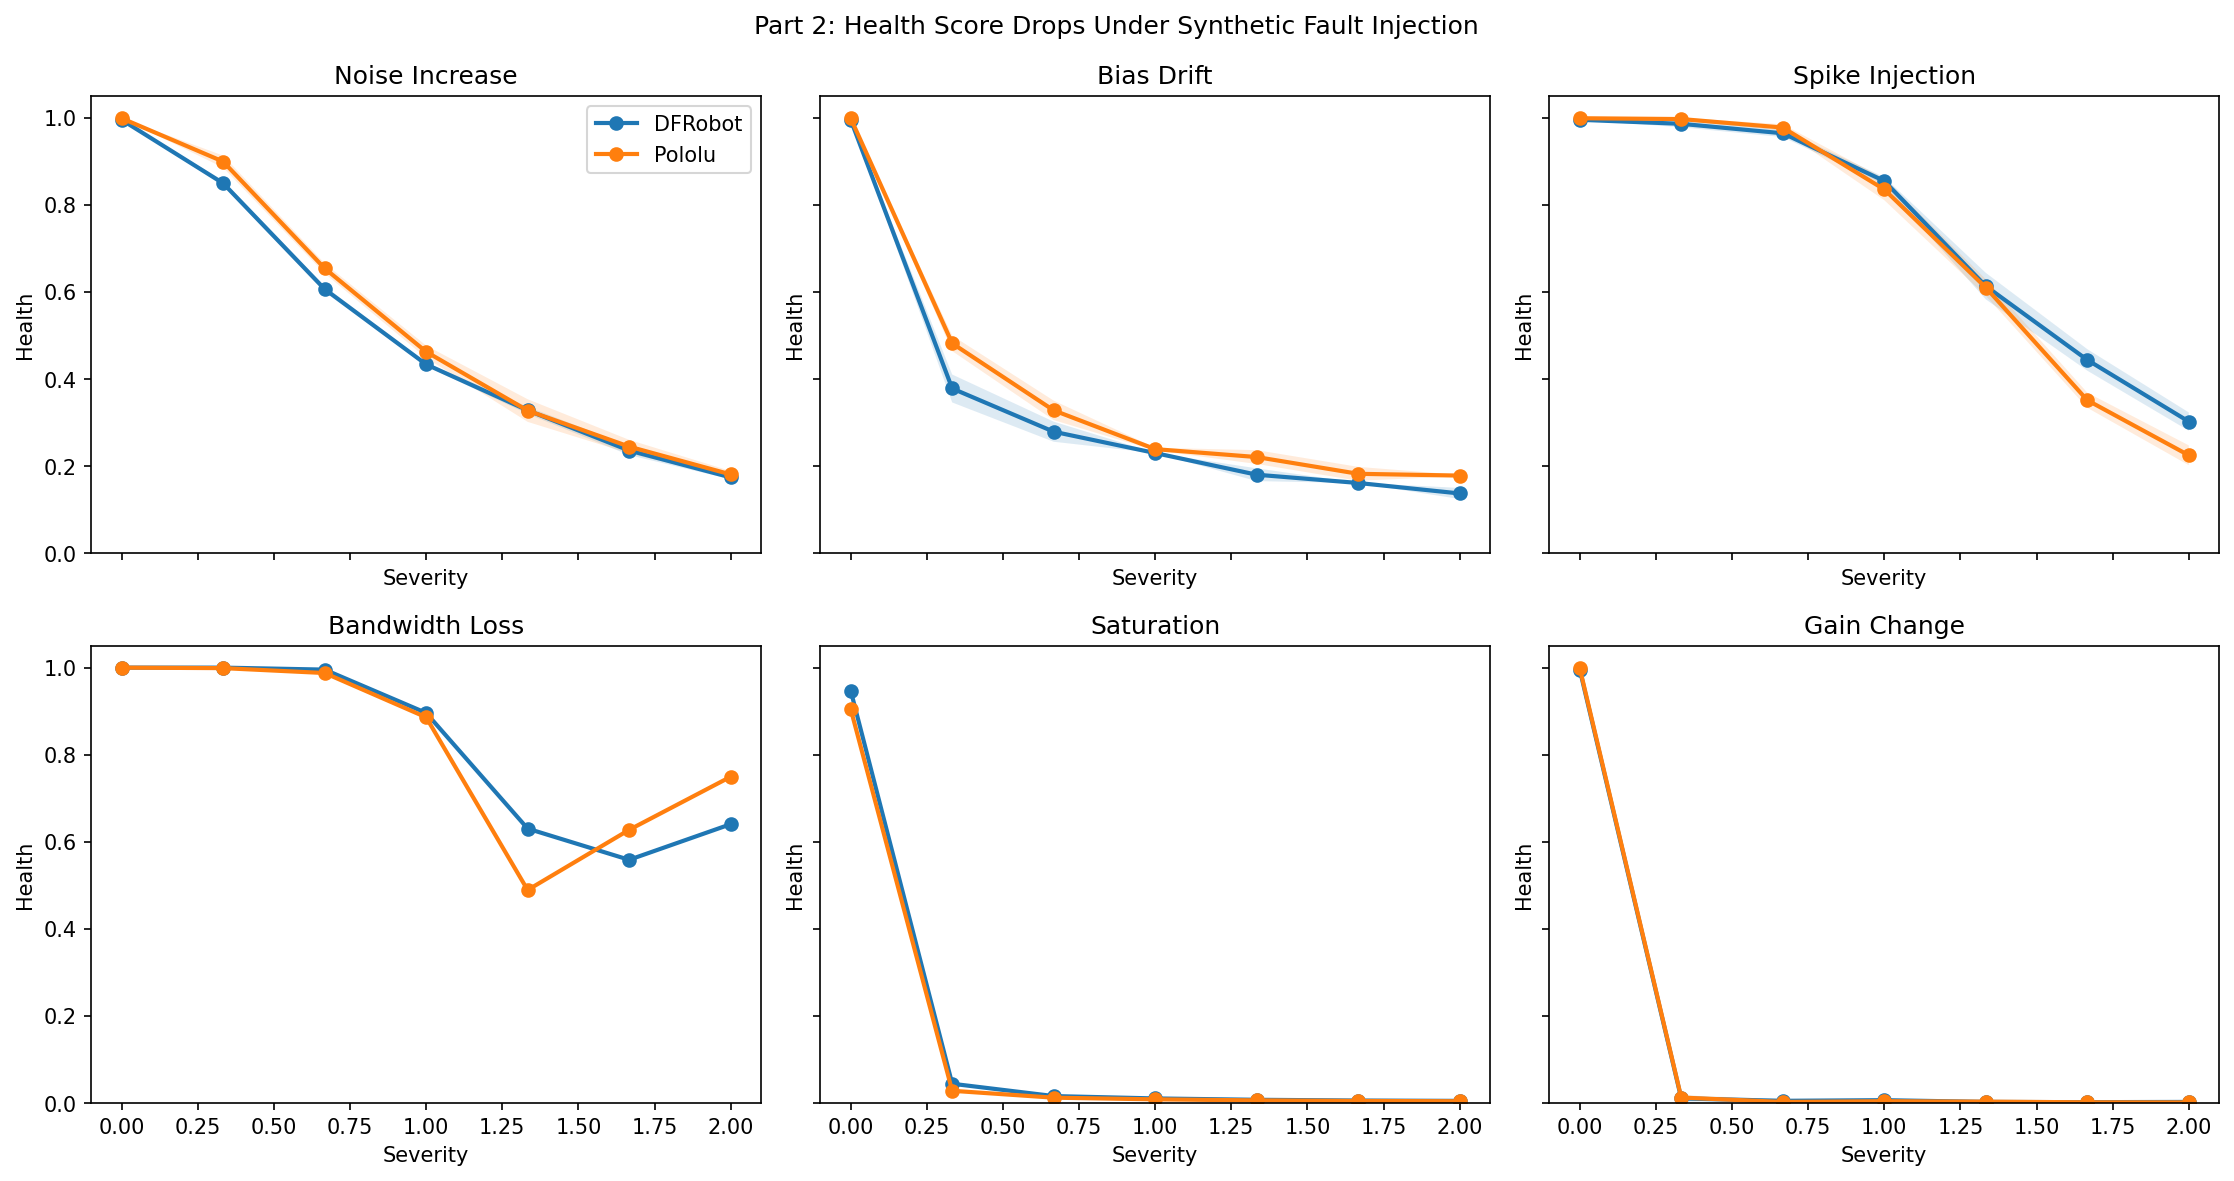

In [3]:
figure_order = [
    ('Raw vs Calibrated Sanity', 'raw_vs_calibrated_sanity.png'),
    ('MODWT Stationary Decomposition', 'modwt_decomposition_stationary.png'),
    ('Healthy Condition Summary', 'healthy_condition_summary.png'),
    ('Healthy Health Timeline', 'healthy_health_timeline.png'),
    ('Healthy Divergence Timeline', 'healthy_divergence_timeline.png'),
    ('Cross-Sensor Divergence', 'cross_sensor_divergence.png'),
    ('Fault Health Response', 'fault_health_response.png'),
    ('Fault Divergence Response', 'fault_divergence_response.png'),
]

for title, filename in figure_order:
    display(Markdown(f"## {title}"))
    display(Image(filename=str(OUT_DIR / filename)))